In [116]:
## SMA(5)/SMA(20) Long Strategy Backtest

# Rules implemented:
# - **Entry**: Buy when the 5-day SMA crosses above the 20-day SMA.
# - **Exit**: Sell when the 5-day SMA decreases vs the prior day.
# - **Stop loss**: Stop at the **low of the entry day** (placed right after the entry fills).

# Data source (per `AGENTS.md`):
# - Load inter-day data via `strategies.data`.
# - `symbols` is a dict keyed by symbol where values are `SymbolData` objects.
# - Each `SymbolData` has `.df` containing OHLCV (plus indicators already computed).

In [117]:
# Setup: imports + (optional) dependency installs
import sys
import subprocess
import importlib


def ensure_package(pip_name: str, import_name: str | None = None) -> None:
    import_name = import_name or pip_name
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
        importlib.import_module(import_name)


ensure_package("pandas")
ensure_package("numpy")
ensure_package("matplotlib")
ensure_package("backtrader")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import backtrader as bt

from strategies.data import add_market_data_to_syspath, load_daily_variables

pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8")

In [118]:
# Parameters


# Data location
# - If you have a full path to the pickle, set DAILY_VARIABLES_PATH.
# - Otherwise, we load from MARKET_DATA_ROOT\scripts\<filename> (see strategies.utils.config).
DAILY_VARIABLES_PATH = None  # e.g. r"C:\\path\\to\\daily_variables.pkl"
DAILY_VARIABLES_FILENAME = "daily_variables.pkl"  # used when DAILY_VARIABLES_PATH is None

INITIAL_CASH = 100_000.0
COMMISSION = 0.001  # 0.1% per trade

# Load preprocessed inter-day data via strategies.data (per AGENTS.md)
# NOTE: unpickling often requires the sibling `market_data` repo to be importable.
add_market_data_to_syspath()

if DAILY_VARIABLES_PATH:
    from strategies.data import load_pickled_variables

    symbols = load_pickled_variables(DAILY_VARIABLES_PATH)
else:
    symbols = load_daily_variables(filename=DAILY_VARIABLES_FILENAME)

if not isinstance(symbols, dict):
    raise TypeError(f"Expected `symbols` to be a dict, got: {type(symbols)!r}")



Loading Variables: 100%|██████████| 26/26 [05:35<00:00, 12.90s/it]  


In [119]:
SYMBOL = "NVDA"  # change as desired

if SYMBOL not in symbols:
    available = sorted(list(symbols.keys()))
    raise KeyError(f"{SYMBOL!r} not in symbols. Example available symbols: {available[:20]}")

symbol_data = symbols[SYMBOL]
df_raw = symbol_data.df.copy()
df_raw.tail()

,Open,High,Low,Close,Volume,VWAP,5DMA,10DMA,20DMA,50DMA,200DMA,AvgV20,RVol,Dollar_Volume,AvgDV20,TR,ATR_14,ATRs_from_5DMA,ATRs_from_10DMA,ATRs_from_20DMA,ATRs_from_50DMA,ATRs_from_200DMA,ATR_14_signal,RSI_14,RSI_14_signal,...,ma_st,ma_mt,ma_lt,regime_crossing_ma_long_2050200,regime_crossing_ma_short_2050200,regime_crossing_ma_long_102050,regime_crossing_ma_short_102050,triple_ma2050200,Hi1,Lo1,Hi2,Lo2,Hi3,Lo3,Hi4,Lo4,rg,flr,clg,rg_ch,consolidation,acc_dist,w_acc_dist,c_over_under_20DMA,ep
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-02-09,184.260,198.725,183.95,190.04,196435875.0,190.5406,180.372,185.115,184.9345,183.8112,170.11045,1.768859e+08,1.110523,3.733067e+10,3.263924e+10,14.775,7.058295,1.369736,0.697761,0.723333,0.882479,2.823564,5.952333,55.357153,48.421148,...,184.9345,183.8112,170.11045,1.0,NaN,NaN,-1.0,1.0,198.725,NaN,198.725,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,198.725,1.0,NaN,-4.641359e+08,NaN,NaN
2026-02-10,191.380,192.480,188.12,188.54,136808388.0,189.4238,182.012,185.117,185.1145,183.9768,170.52100,1.768419e+08,0.773620,2.579385e+10,3.265572e+10,4.360,6.865560,0.950833,0.498576,0.498940,0.664651,2.624549,6.134979,53.739659,49.484850,...,185.1145,183.9768,170.52100,1.0,NaN,NaN,-1.0,1.0,NaN,188.12,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,198.725,1.0,NaN,-6.009443e+08,NaN,NaN
2026-02-11,192.450,193.260,188.77,190.05,144171547.0,191.1817,185.184,184.970,185.3265,184.2378,170.91620,1.761265e+08,0.818568,2.739980e+10,3.255336e+10,4.720,6.712305,0.724937,0.756819,0.703708,0.865902,2.850556,6.250444,55.160039,50.619888,...,185.3265,184.2378,170.91620,1.0,NaN,NaN,1.0,1.0,193.260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,198.725,1.0,NaN,-7.451159e+08,NaN,NaN
2026-02-12,193.030,193.610,186.51,186.94,189648445.0,189.2573,188.196,184.413,185.5165,184.3782,171.30725,1.777005e+08,1.067237,3.545288e+10,3.287765e+10,7.100,6.739998,-0.186350,0.374926,0.211202,0.380089,2.319400,6.348355,51.643015,50.824513,...,185.5165,184.3782,171.30725,1.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,198.725,1.0,NaN,-9.347643e+08,NaN,NaN
2026-02-13,187.475,187.500,181.59,182.81,161876983.0,183.6369,187.676,183.581,185.3045,184.4052,171.67620,1.754686e+08,0.922541,2.959273e+10,3.242585e+10,5.910,6.680712,-0.728365,-0.115407,-0.373388,-0.238777,1.666559,6.414826,47.327446,50.125100,...,185.3045,184.4052,171.67620,1.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,198.725,1.0,NaN,-1.096641e+09,1.0,NaN


In [120]:
# Prepare dataframe for backtrader
# Your SymbolData.df may include many indicators; we only need OHLCV.
df = df_raw.copy()

# Ensure a DatetimeIndex
if not isinstance(df.index, pd.DatetimeIndex):
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
        df = df.set_index("date")
    else:
        raise TypeError("Expected SymbolData.df to have a DatetimeIndex (or a `date` column).")

if getattr(df.index, "tz", None) is not None:
    df.index = df.index.tz_convert(None)

df = df.sort_index()

# Normalize column names (keep indicators, but standardize the price columns)
df = df.rename(columns={c: str(c).lower().replace(" ", "_") for c in df.columns})

# Prefer `close` if present; fall back to `adj_close`
if "close" not in df.columns and "adj_close" in df.columns:
    df["close"] = df["adj_close"]

required = ["open", "high", "low", "close", "volume"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required OHLCV columns in SymbolData.df: {missing}")

# Use precomputed moving averages from SymbolData.df (AGENTS.md requirement)
fast_candidates = ["5dma", "sma_5", "ma_5", "dma_5"]
slow_candidates = ["20dma", "sma_20", "ma_20", "dma_20"]

fast_col = next((c for c in fast_candidates if c in df.columns), None)
slow_col = next((c for c in slow_candidates if c in df.columns), None)

if fast_col is None or slow_col is None:
    ma_like = [c for c in df.columns if "ma" in c or "dma" in c]
    raise ValueError(
        "Could not find precomputed 5/20 MA columns in SymbolData.df. "
        f"Found MA-like columns (sample): {ma_like[:30]}"
    )

# Keep a clean feed frame with OHLCV + precomputed MA columns used by strategy
df_feed = df[["open", "high", "low", "close", "volume", fast_col, slow_col]].dropna().copy()
df_feed = df_feed.rename(columns={fast_col: "ma_fast", slow_col: "ma_slow"})

# Ensure numeric dtypes (Backtrader can behave oddly with object/nullable dtypes)
for col in ["open", "high", "low", "close", "volume", "ma_fast", "ma_slow"]:
    df_feed[col] = pd.to_numeric(df_feed[col], errors="coerce")

df_feed = df_feed.dropna()

print(
    f"Bars: {len(df_feed):,} | Date range: {df_feed.index.min().date()} -> {df_feed.index.max().date()} | "
    f"MA columns: {fast_col}/{slow_col}"
)

# Sanity-check: cross-ups from precomputed MA columns
entries = (df_feed["ma_fast"] > df_feed["ma_slow"]) & (df_feed["ma_fast"].shift(1) <= df_feed["ma_slow"].shift(1))
print(f"Precomputed MA cross-up count (fast crosses above slow): {int(entries.sum())}")

df_feed.head()

Bars: 2,513 | Date range: 2016-02-18 -> 2026-02-13 | MA columns: 5dma/20dma
Precomputed MA cross-up count (fast crosses above slow): 78


,open,high,low,close,volume,ma_fast,ma_slow
Date,,,,,,,
2016-02-18,0.7483,0.7744,0.7475,0.7510,1.068626e+09,0.0000,0.0
2016-02-19,0.7470,0.7678,0.7413,0.7610,5.256293e+08,0.0000,0.0
2016-02-22,0.7720,0.7968,0.7705,0.7880,4.496679e+08,0.0000,0.0
2016-02-23,0.7817,0.7975,0.7780,0.7900,3.693780e+08,0.0000,0.0
2016-02-24,0.7867,0.7967,0.7650,0.7955,3.368534e+08,0.7771,0.0


In [121]:
# Strategy implementation (Backtrader)
class TradeCaptureAnalyzer(bt.Analyzer):
    """Collect closed-trade metadata (including entry/exit prices)."""

    def start(self) -> None:
        self.trades: list[dict] = []

    @staticmethod
    def _safe_history_value(trade, index: int, attr: str):
        try:
            return float(getattr(trade.history[index].event, attr))
        except Exception:
            return None

    def notify_trade(self, trade) -> None:
        if not trade.isclosed:
            return

        data_name = trade.data._name or "UNKNOWN"
        entry_dt = bt.num2date(trade.dtopen)
        exit_dt = bt.num2date(trade.dtclose)

        # Backtrader trades keep a history of fills. Use that for stable size/prices.
        entry_price = self._safe_history_value(trade, 0, "price")
        exit_price = self._safe_history_value(trade, -1, "price")
        size = self._safe_history_value(trade, 0, "size")

        self.trades.append(
            {
                "symbol": data_name,
                "entry_date": entry_dt.date().isoformat(),
                "exit_date": exit_dt.date().isoformat(),
                "size": size,
                "entry_price": entry_price,
                "exit_price": exit_price,
                "pnl": float(trade.pnlcomm),
            }
        )

    def get_analysis(self):
        return self.trades


class SmaCrossWithMaDownExitAndEntryLowStop(bt.Strategy):
    """Long-only strategy.

    - Entry: SMA(5) crosses above SMA(20)
    - Exit: On the *first day after entry*, exit if SMA(5) decreased vs the prior day.
    - Stop: Exit if the close falls below the low of the entry day.

    Practical notes:
    - Some datasets begin *after* a crossover already happened. If you still want
      an entry when the backtest starts in an "already above" regime, set
      `enter_on_start_if_above=True`.
    - If you want the final open position to be closed (so it shows up in the
      closed-trade table), set `close_on_last_bar=True`.

    Important: sizing must account for commission, otherwise orders can be rejected.
    """

    params = dict(
        enter_on_start_if_above=True,
        close_on_last_bar=True,
        size_cash_buffer=0.98,  # keep 2% cash reserve to avoid margin rejects
    )

    def __init__(self) -> None:
        # Use precomputed MA lines from the source dataframe.
        self.ma_fast = self.data.ma_fast
        self.ma_slow = self.data.ma_slow
        self.crossover = bt.ind.CrossOver(self.ma_fast, self.ma_slow)

        self.entry_order = None
        self._last_dt = None

        self._entry_dt = None
        self._entry_low = None
        self._bars_since_entry = None

    def start(self) -> None:
        # With default `preload=True`, we can peek the last bar's date.
        if self.p.close_on_last_bar:
            self._last_dt = self.data.datetime.date(-1)

    def nextstart(self) -> None:
        # Called once when indicators are "ready" (minperiod reached).
        if not self.p.enter_on_start_if_above:
            return
        if self._last_dt is not None and self.data.datetime.date(0) == self._last_dt:
            return
        if self.position or self.entry_order:
            return
        if self.ma_fast[0] > self.ma_slow[0]:
            size = self._calc_size_all_in()
            if size > 0:
                self.entry_order = self.buy(size=size)

    def _calc_size_all_in(self) -> int:
        """Size so (cost + commission) <= cash with a small reserve."""
        price = float(self.data.close[0])
        if price <= 0:
            return 0

        cash = float(self.broker.getcash())
        if cash <= 0:
            return 0

        comminfo = self.broker.getcommissioninfo(self.data)

        # Keep a reserve to avoid next-bar/open price and commission edge rejects.
        budget = cash * float(self.p.size_cash_buffer)
        size = int(budget // price)

        while size > 0:
            commission = abs(float(comminfo.getcommission(size, price)))
            total_cost = size * price + commission
            if total_cost <= cash:
                break
            size -= 1
        return max(size, 0)

    def notify_order(self, order) -> None:
        if order.status in [order.Submitted, order.Accepted]:
            return

        if order.status in [order.Margin, order.Rejected]:
            dt = self.data.datetime.date(0)
            print(f"ORDER {order.getstatusname()} on {dt} | isbuy={order.isbuy()} size={order.size} price={order.created.price}")

        if order.status in [order.Canceled, order.Margin, order.Rejected]:
            if order is self.entry_order:
                self.entry_order = None
            return

        if order.status != order.Completed:
            return

        if order.isbuy():
            # Entry filled: remember the entry-day low for the stop logic.
            self.entry_order = None
            self._entry_dt = self.data.datetime.date(0)
            self._entry_low = float(self.data.low[0])
            self._bars_since_entry = 0

    def next(self) -> None:
        # If we have a pending entry order, do nothing.
        if self.entry_order:
            return

        # Optionally close any open position on the last bar.
        if self._last_dt is not None and self.data.datetime.date(0) == self._last_dt:
            if self.position:
                self.close()
            return

        # Not in position: look for entry.
        if not self.position:
            self._entry_dt = None
            self._entry_low = None
            self._bars_since_entry = None

            if self.crossover[0] > 0:
                size = self._calc_size_all_in()
                if size > 0:
                    self.entry_order = self.buy(size=size)
            return

        # In position: manage exits.
        self._bars_since_entry = 0 if self._bars_since_entry is None else self._bars_since_entry + 1

        # Stop: exit if close < entry-day low (your requested interpretation).
        if self._entry_low is not None and float(self.data.close[0]) < float(self._entry_low):
            self.close()
            return

        # Exit rule: only check the *first day after entry*.
        if self.ma_fast[0] < self.ma_fast[-1]:
            self.close()
            return

In [122]:
# Run backtest
cerebro = bt.Cerebro()

cerebro.broker.setcash(INITIAL_CASH)
cerebro.broker.setcommission(commission=COMMISSION)

# Execute market orders on close so sizing uses the same bar's close price.
cerebro.broker.set_coc(True)

class PandasDataNoOpenInterest(bt.feeds.PandasData):
    lines = ("ma_fast", "ma_slow")
    params = (("openinterest", -1), ("ma_fast", -1), ("ma_slow", -1))

feed = PandasDataNoOpenInterest(dataname=df_feed)
cerebro.adddata(feed, name=SYMBOL)

cerebro.addstrategy(SmaCrossWithMaDownExitAndEntryLowStop)

cerebro.addanalyzer(TradeCaptureAnalyzer, _name="trade_capture")
cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name="tradeanalyzer")
cerebro.addanalyzer(bt.analyzers.TimeReturn, _name="timereturn")
cerebro.addanalyzer(bt.analyzers.DrawDown, _name="drawdown")

start_value = float(cerebro.broker.getvalue())
results = cerebro.run()
strat = results[0]
end_value = float(cerebro.broker.getvalue())

print(f"Start: {start_value:,.2f}")
print(f"End:   {end_value:,.2f}")
print(f"Net:   {end_value - start_value:,.2f} ({(end_value / start_value - 1) * 100:.2f}%)")
print(f"End position size: {getattr(strat.position, 'size', None)}")

ta = strat.analyzers.tradeanalyzer.get_analysis()
print("TradeAnalyzer summary (total/open/closed):", ta.get("total"), ta.get("open"), ta.get("closed"))

trades = pd.DataFrame(strat.analyzers.trade_capture.get_analysis())
trades

Start: 100,000.00
End:   340,855.86
Net:   240,855.86 (240.86%)
End position size: 0
TradeAnalyzer summary (total/open/closed): AutoOrderedDict({'total': 76, 'open': 0, 'closed': 76}) None None


,symbol,entry_date,exit_date,size,entry_price,exit_price,pnl
0,NVDA,2016-05-16,2016-06-08,None,None,None,12589.974883
1,NVDA,2016-07-07,2016-07-22,None,None,None,12658.998206
2,NVDA,2016-09-21,2016-10-07,None,None,None,8010.625605
3,NVDA,2016-10-25,2016-11-02,None,None,None,-3323.849149
4,NVDA,2016-12-16,2017-01-03,None,None,None,10090.891356
...,...,...,...,...,...,...,...
71,NVDA,2025-09-16,2025-09-18,None,None,None,-15873.745320
72,NVDA,2025-10-29,2025-10-31,None,None,None,2504.457600
73,NVDA,2025-12-11,2025-12-12,None,None,None,-6091.875450
74,NVDA,2025-12-26,2025-12-31,None,None,None,-2624.762250


In [123]:
# Equity curve + baseline comparison
rets = strat.analyzers.timereturn.get_analysis()
ret_s = pd.Series(rets)
ret_s.index = pd.to_datetime(ret_s.index)
ret_s = ret_s.sort_index()

strategy_equity = (1.0 + ret_s).cumprod() * INITIAL_CASH

# Buy & hold baseline (invest all cash on first day close)
close = df_feed["close"].copy()
bh_ret = close.pct_change().fillna(0.0)
bh_equity = (1.0 + bh_ret).cumprod() * INITIAL_CASH

# Drawdown stats
dd = strat.analyzers.drawdown.get_analysis()
max_dd_pct = float(dd.max.drawdown)
max_dd_len = int(dd.max.len)

summary = pd.DataFrame(
    {
        "metric": [
            "strategy_final",
            "strategy_return_%",
            "buyhold_final",
            "buyhold_return_%",
            "max_drawdown_%",
            "max_drawdown_len",
            "num_trades",
        ],
        "value": [
            float(strategy_equity.iloc[-1]),
            float((strategy_equity.iloc[-1] / INITIAL_CASH - 1) * 100),
            float(bh_equity.iloc[-1]),
            float((bh_equity.iloc[-1] / INITIAL_CASH - 1) * 100),
            max_dd_pct,
            max_dd_len,
            int(len(trades)),
        ],
    }
)

summary

,metric,value
0,strategy_final,3.408559e+05
1,strategy_return_%,2.408559e+02
2,buyhold_final,2.434221e+07
3,buyhold_return_%,2.424221e+04
4,max_drawdown_%,3.162949e+01
5,max_drawdown_len,7.590000e+02
6,num_trades,7.600000e+01


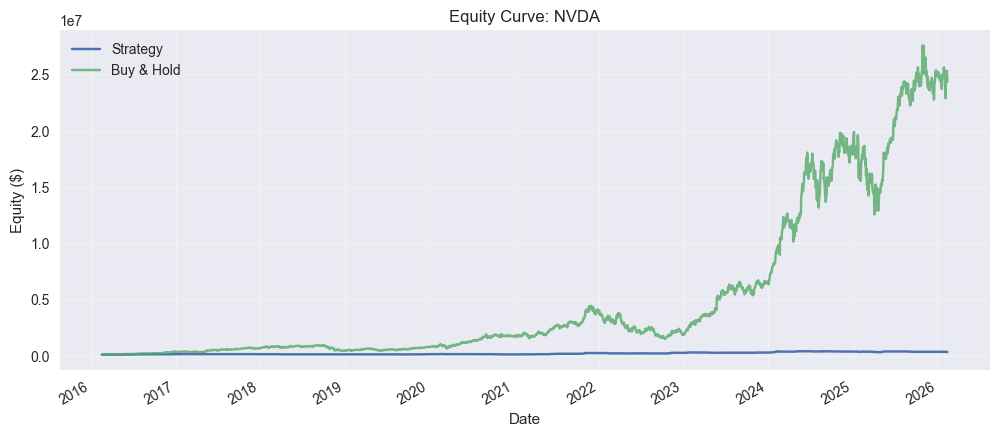

In [124]:
# Plot equity curves
fig, ax = plt.subplots(figsize=(12, 5))
strategy_equity.plot(ax=ax, label="Strategy")
bh_equity.plot(ax=ax, label="Buy & Hold", alpha=0.8)
ax.set_title(f"Equity Curve: {SYMBOL}")
ax.set_ylabel("Equity ($)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [125]:
# Optional: Backtrader's built-in price/indicator plot
# (Can be slow on long date ranges.)
# cerebro.plot(iplot=False, volume=False, style="candlestick")